# BIND2 Appendix — Low-mass breakdown (10¹²–10¹³ M⊙)

BIND trains on halos ≥10¹³ but generates the smaller halos inside its 6.25 Mpc/h patches. The main-text parameter-response figures use the trained ≥10¹³ regime; here we break out the **10¹²–10¹³ extrapolation regime** — its integrated-mass & profile fidelity and its parameter response (the `lowmass` window of the same caches). Same load-only cache.

In [1]:

import sys
sys.path.insert(0, '/mnt/home/mlee1/vdm_bind2/tools/paper_cache')
import os, pickle
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import paper_config as C

CACHE = C.CACHE_DIR
def L(name):
    p = CACHE / name
    if name.endswith('.pkl'):
        return pickle.load(open(p, 'rb'))
    return dict(np.load(p, allow_pickle=False))

FIG_DIR = Path('paper_figures'); FIG_DIR.mkdir(exist_ok=True)
def save_fig(fig, name, ext=('pdf', 'png')):
    for e in ext:
        fig.savefig(FIG_DIR / f'{name}.{e}', dpi=300, bbox_inches='tight')
    print('  saved', name)

try:
    import scienceplots  # noqa: F401
    plt.style.use(['science', 'notebook'])
except Exception:
    pass
plt.rcParams.update({'font.size': 10, 'font.family': 'serif', 'mathtext.fontset': 'cm',
                     'figure.dpi': 110, 'savefig.dpi': 300, 'axes.grid': False})

SUITE_COLORS = C.SUITE_COLORS; SUITE_DISPLAY = C.SUITE_DISPLAY
MASS_CH = C.MASS_CHANNELS; CH_DISPLAY = C.CH_DISPLAY
BIN_LABELS = C.MASS_BIN_LABELS; N_BINS = C.N_MASS_BINS
PARAM_LABELS = C.PARAM_LABELS
BIN_CMAP = plt.cm.viridis(np.linspace(0.1, 0.9, N_BINS))
print('Cache :', CACHE)
print('Model :', C.MODEL_TAG, '| suites', {s: 0 for s in C.SUITES})
print('Files :', sorted(p.name for p in CACHE.glob("*.pkl")) + sorted(p.name for p in CACHE.glob("*.npz")))


Cache : /mnt/home/mlee1/ceph/paper_cache/fm_thermo
Model : fm_thermo | suites {'CV': 0, '1P': 0, 'Test': 0}
Files : ['mass_param.pkl', 'mass_table.pkl', 'profiles.pkl', 'profiles_r200.pkl', 'shapes.pkl', 'thermo_param.pkl', 'thermo_profiles.pkl', 'thermo_scaling.pkl', 'covering.npz', 'field1p.npz', 'observables.npz', 'pk.npz', 'redshift_evo.npz', 'thermo_pixels.npz', 'vdm_fm.npz']


In [2]:

WIN = 'lowmass'
LOWBINS = [b for b in range(N_BINS) if C.MASS_EDGES[b] < 13.0]   # [12,12.5),[12.5,13)
astro = [j for j in range(C.N_PARAMS) if (j+1) not in C.COSMO_PARAM_IDX]
order = sorted(astro); xl = [PARAM_LABELS[j+1] for j in order]
def phm(ax, data, rowlabels, title=None, vmax=0.5, annot=False):
    im = ax.imshow(data, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_yticks(range(len(rowlabels))); ax.set_yticklabels(rowlabels)
    ax.set_xticks(range(len(xl))); ax.set_xticklabels(xl, rotation=45, ha='right', fontsize=7)
    if title: ax.set_title(title)
    if annot:
        for i in range(data.shape[0]):
            for k in range(data.shape[1]):
                if np.isfinite(data[i,k]): ax.text(k,i,f'{data[i,k]:.2f}',ha='center',va='center',fontsize=6,color='white' if abs(data[i,k])>0.45 else 'k')
    return im
print('low-mass bins:', [BIN_LABELS[b] for b in LOWBINS])


low-mass bins: ['[12.0, 12.5)', '[12.5, 13.0)']


## §L1 · Integrated mass & profile fidelity (10¹²–10¹³)

  saved figL1a_lowmass_mass_residual


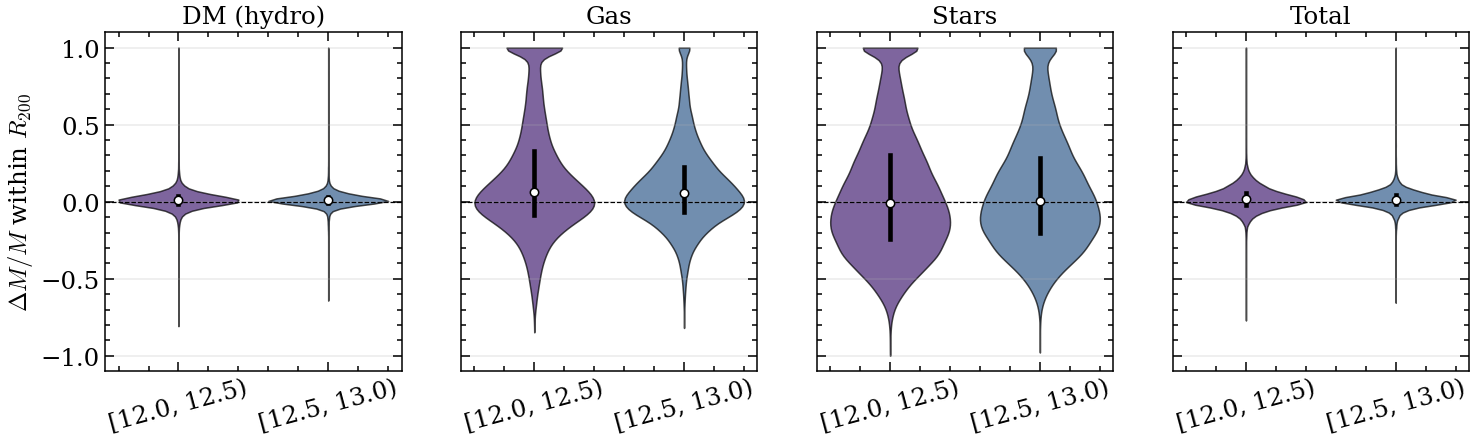

In [3]:

tbl = L('mass_table.pkl'); low = tbl[tbl.mass_bin.isin(LOWBINS)]
ch_keys = MASS_CH + ['Total']
fig, axes = plt.subplots(1, len(ch_keys), figsize=(4*len(ch_keys), 4), sharey=True)
for ax, ch in zip(axes, ch_keys):
    data = []
    for b in LOWBINS:
        sub = low[low.mass_bin==b]
        if ch=='Total':
            t=sum(sub[f'truth_{k}_rvir'] for k in MASS_CH); g=sum(sub[f'gen_{k}_rvir'] for k in MASS_CH)
        else:
            t=sub[f'truth_{ch}_rvir']; g=sub[f'gen_{ch}_rvir']
        with np.errstate(divide='ignore',invalid='ignore'):
            r=((g-t)/t).to_numpy(); data.append(np.clip(r[np.isfinite(r)],-1,1))
    parts=ax.violinplot(data, positions=range(len(LOWBINS)), widths=0.8, showextrema=False)
    for pc,cc in zip(parts['bodies'], BIN_CMAP[LOWBINS]): pc.set_facecolor(cc); pc.set_alpha(0.7); pc.set_edgecolor('k')
    for i,r in enumerate(data):
        q1,me,q3=np.percentile(r,[25,50,75]); ax.plot([i,i],[q1,q3],'k',lw=3); ax.scatter([i],[me],color='w',s=30,zorder=6,ec='k')
    ax.axhline(0,color='k',ls='--',lw=0.8); ax.set_title(CH_DISPLAY.get(ch,ch)); ax.set_xticks(range(len(LOWBINS))); ax.set_xticklabels([BIN_LABELS[b] for b in LOWBINS], rotation=15)
    ax.grid(axis='y',alpha=0.25)
axes[0].set_ylabel(r'$\Delta M/M$ within $R_{200}$')
save_fig(fig, 'figL1a_lowmass_mass_residual'); plt.show()


  saved figL1b_lowmass_profiles


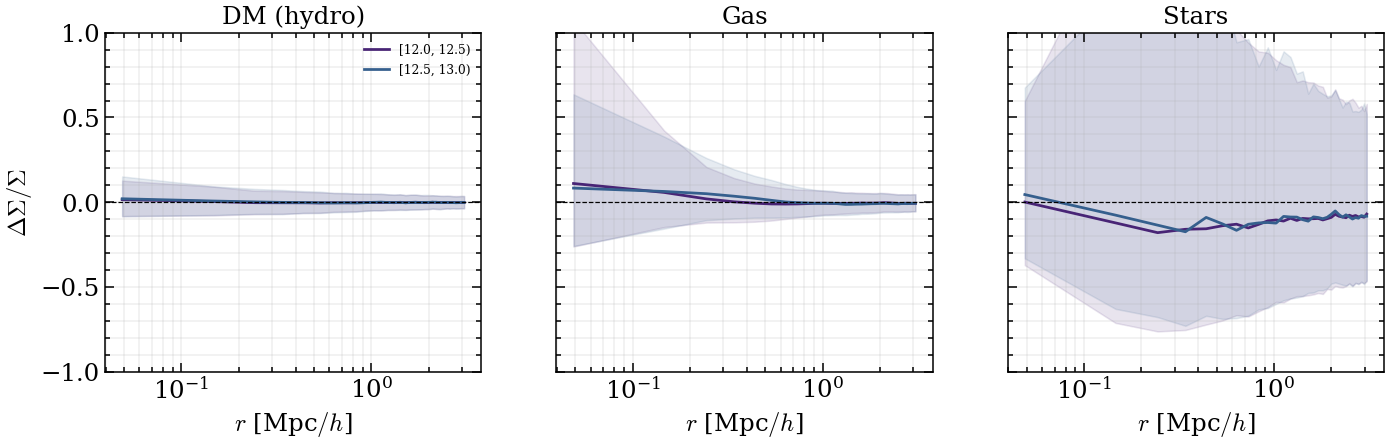

In [4]:

pr = L('profiles.pkl'); r = pr['r']
fig, axes = plt.subplots(1, len(MASS_CH), figsize=(5*len(MASS_CH), 4), sharey=True)
for c, ax in enumerate(axes):
    for b in LOWBINS:
        if b not in pr['by_bin']: continue
        band = pr['by_bin'][b]
        ax.plot(r, band['pctdiff_med'][c], color=BIN_CMAP[b], lw=1.8, label=BIN_LABELS[b])
        ax.fill_between(r, band['pctdiff_p16'][c], band['pctdiff_p84'][c], color=BIN_CMAP[b], alpha=0.12)
    ax.axhline(0,color='k',ls='--',lw=0.8); ax.set_xscale('log'); ax.set_ylim(-1,1)
    ax.set_title(CH_DISPLAY[MASS_CH[c]]); ax.set_xlabel(r'$r$ [Mpc$/h$]'); ax.grid(which='both',alpha=0.2)
    if c==0: ax.set_ylabel(r'$\Delta\Sigma/\Sigma$'); ax.legend(fontsize=8)
save_fig(fig, 'figL1b_lowmass_profiles'); plt.show()


## §L2 · Parameter response in the extrapolation regime (10¹²–10¹³)

Does BIND reproduce how low-mass halos respond to feedback? Left = BIND response, right = True−BIND residual (small ⇒ captured).

  saved figL2a_lowmass_param_mass


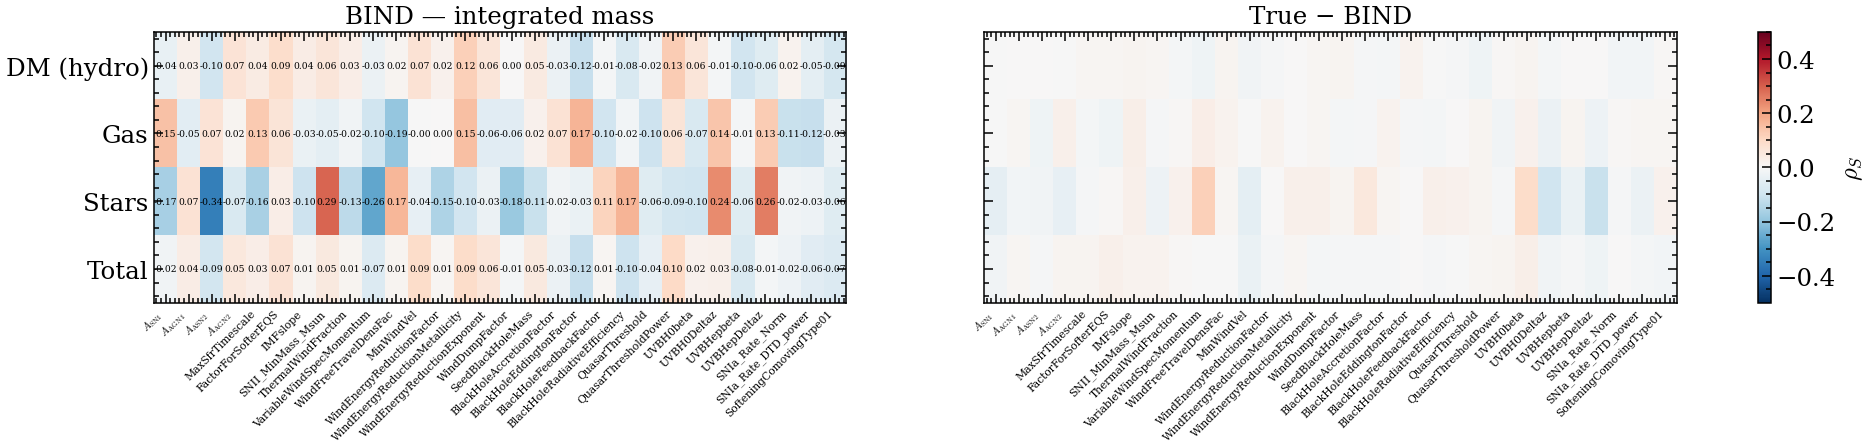

In [5]:

# mass parameter response (low-mass window)
mp = L('mass_param.pkl'); rm = mp['rho_mass'][WIN]; chans = mp['channels']
fig, ax = plt.subplots(1, 2, figsize=(19, 3.2), sharey=True)
phm(ax[0], rm['BIND'][:, order], [CH_DISPLAY.get(c,c) for c in chans], 'BIND — integrated mass', annot=True)
im = phm(ax[1], (rm['True']-rm['BIND'])[:, order], [CH_DISPLAY.get(c,c) for c in chans], 'True − BIND')
fig.colorbar(im, ax=ax, fraction=0.01).set_label(r'$\rho_S$')
save_fig(fig, 'figL2a_lowmass_param_mass'); plt.show()


  saved figL2b_lowmass_param_thermo


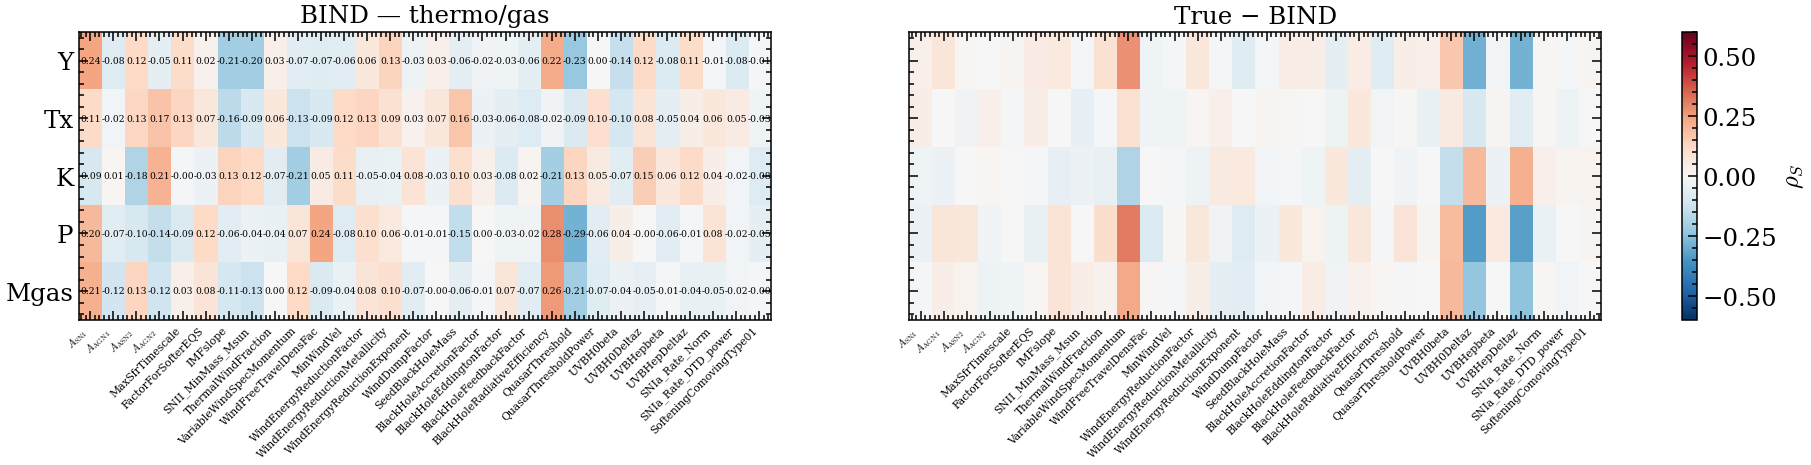

In [6]:

# thermo parameter response (low-mass window)
tpar = L('thermo_param.pkl'); rt = tpar['rho_thermo'][WIN]; keys = list(tpar['keys'])
fig, ax = plt.subplots(1, 2, figsize=(19, 3.4), sharey=True)
phm(ax[0], rt['BIND'][:, order], keys, 'BIND — thermo/gas', vmax=0.6, annot=True)
im = phm(ax[1], (rt['True']-rt['BIND'])[:, order], keys, 'True − BIND', vmax=0.6)
fig.colorbar(im, ax=ax, fraction=0.01).set_label(r'$\rho_S$')
save_fig(fig, 'figL2b_lowmass_param_thermo'); plt.show()


  saved figL2c_lowmass_param_profile_gas


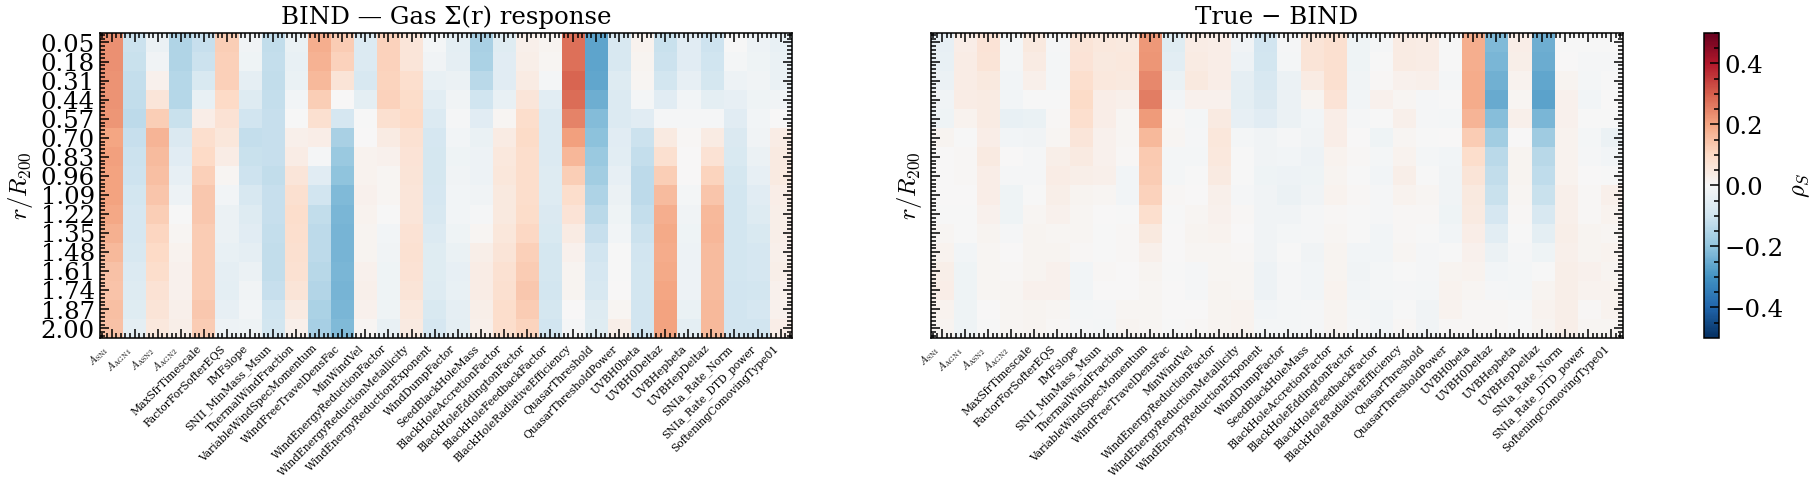

In [7]:

# profile parameter response (low-mass window): Gas channel, BIND vs residual
p2 = L('profiles_r200.pkl'); rr = p2['r_over_r200']; rp = p2['rho_prof'][WIN]
gi = MASS_CH.index('Gas')
rlab = [f'{v:.2f}' for v in rr]
fig, ax = plt.subplots(1, 2, figsize=(19, 3.6), sharey=True)
phm(ax[0], rp['BIND'][gi][:, order], rlab, 'BIND — Gas Σ(r) response')
im = phm(ax[1], (rp['True'][gi]-rp['BIND'][gi])[:, order], rlab, 'True − BIND')
for a in ax: a.set_ylabel(r'$r/R_{200}$')
fig.colorbar(im, ax=ax, fraction=0.01).set_label(r'$\rho_S$')
save_fig(fig, 'figL2c_lowmass_param_profile_gas'); plt.show()
